### Plot IUIS-IEI membership among pipeline hits
### Julian Moran
### 2026-08-20

In [1]:
import boto3
import glob
import logging
import os
import s3fs

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from dotenv import load_dotenv

# Env
load_dotenv("../.env", override=True)
REPO_ROOT = os.environ["INSTALL_PATH"]
MINIO_KEY = os.environ["MINIO_KEY"]
MINIO_SECRET = os.environ["MINIO_SECRET"]

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger(__name__)

### Notebook goal

- Repeat the analysis performed in `plot_IUIS_membership.ipynb`
    + only this time, pare dataset down to only one row per unique human gene name
    + take top-scoring row per gene


### Data sources

1. `FILE_GOLD_STD`: in-house manual literature review
2. `FILE_IUIS_IEI`: https://iei-genetics.github.io/?utm_source=chatgpt.com
3. `FILE_COMPOSITE`: pipeline output from  https://github.com/juliandeanmoran/iei-project-pyspark; see `data/READEME_run_w_pyspark.md`

In [2]:
# ============================================================
#       Args
# ============================================================

FILE_GOLD_STD = f"{REPO_ROOT}/lit_review_manual/___bacterial_immuneSystem_goldStandard_manual_include.tsv"
FILE_IUIS_IEI = f"{REPO_ROOT}/data_sync/IUIS-IEI_geneList_cleaned.tsv"

# MinIO
BUCKET = "iei-project"
PREFIX_GOLD = "03_gold/defense_finder/"
PREFIX_SILVER = "02_silver/defense_finder/"
FILE_COMPOSITE = "human_bacteria_structural_analogs_enriched.parquet"

# Dirs
OUT_DIR_PLOT = f"{REPO_ROOT}/vis/plots"

# Check live objects in MinIO silver
client = boto3.client(
    "s3",
    endpoint_url="http://eagle.tcag.ca:9000",
    aws_access_key_id=MINIO_SECRET,
    aws_secret_access_key=MINIO_KEY,
)
response = client.list_objects_v2(
    Bucket=BUCKET,
    Prefix=PREFIX_GOLD
)
live_objects = [
    obj["Key"]
    for obj in response.get("Contents", [])
]
live_objects

['03_gold/defense_finder/composite_score.parquet/_SUCCESS',
 '03_gold/defense_finder/composite_score.parquet/part-00000-ac5574c4-cf3c-48a9-98b6-077d4db394f9-c000.snappy.parquet',
 '03_gold/defense_finder/conserved_modules.parquet',
 '03_gold/defense_finder/defense_human_domain_annotated.parquet',
 '03_gold/defense_finder/defense_islands.manifest.json',
 '03_gold/defense_finder/defense_islands.parquet',
 '03_gold/defense_finder/final_output.parquet',
 '03_gold/defense_finder/final_output_spark.parquet/_SUCCESS',
 '03_gold/defense_finder/final_output_spark.parquet/part-00000-bb778272-db05-479f-a79a-2d18e89fe363-c000.snappy.parquet',
 '03_gold/defense_finder/griid_gene_subset.parquet',
 '03_gold/defense_finder/human_bacteria_structural_analogs_enriched.manifest.json',
 '03_gold/defense_finder/human_bacteria_structural_analogs_enriched.parquet',
 '03_gold/defense_finder/human_bacteria_structural_analogs_with_scores.manifest.json',
 '03_gold/defense_finder/human_bacteria_structural_analogs_

In [3]:
# ============================================================
#       In
# ============================================================

df_comp_score = (
    pl.read_parquet(
    f"s3://{BUCKET}/{PREFIX_GOLD}{FILE_COMPOSITE}",
    storage_options={
        "aws_endpoint_url": "http://eagle.tcag.ca:9000",
        "aws_access_key_id": MINIO_SECRET,
        "aws_secret_access_key": MINIO_KEY,
    })
    .sort("composite_score", descending=True)
    .unique(subset=["Gene Names (primary)"], keep="first")
)

df_gold_std = pl.read_csv(
    FILE_GOLD_STD,
    separator="\t",
    has_header=True
)
df_iuis_iei = pl.read_csv(
    FILE_IUIS_IEI,
    separator="\t",
    has_header=True,
    null_values="NA",
    infer_schema_length=None,
)

In [4]:
df_comp_score

defense_uniprot_ac,cluster_repId,defense_taxId,human_entryId,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (molecular function),Gene Ontology (GO),Gene Ontology IDs,FunFam,CDD,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,defense_type,defense_subtype,defense_species,defense_sys_id,defense_sys_beg,defense_sys_end,defense_duplicate_count,defense_rank,human_domains,defense_gene_name,tm_score_human,tm_score_bacteria,rmsd,pymol_rmsd,pymol_aligned_atoms,pymol_aligned_residues,human_aligned_start,human_aligned_end,bact_aligned_start,bact_aligned_end,evalue_foldseek,griid_gene,iuis_iei,iuis_diseases,bacterial_length,bacterial_domains,in_conserved_module,module_count,module_partner_genes,plddt_human_mean,plddt_bacteria_mean,tm_pvalue_human,tm_pvalue_bacteria,tm_pvalue,q_value,structure_source_human,structure_source_bacteria,alignment_status,immune_relevant,composite_score,alphafold_model_version,run_date
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,f64,bool,bool,str,i64,str,bool,i64,str,f64,f64,f64,f64,f64,f64,str,str,str,bool,f64,str,str
"""A0A097R5E9""","""A0A6M0RKE7""","""1453496""","""Q9NXF1""","""Q9NXF1""","""reviewed""","""TEX10_HUMAN""","""Testis-expressed protein 10""","""TEX10 L18 Nbla10363""","""Homo sapiens (Human)""","""929""",null,"""L18 Nbla10363""","""TEX10""",null,"""UP000005640: Chromosome 9""",null,"""mitochondrion [GO:0005739]; ML…",null,"""mitochondrion [GO:0005739]; ML…","""GO:0005634; GO:0005654; GO:000…","""1.25.10.10:FF:000498;""",null,"""1.25.10.10;""","""IPR011989;IPR016024;IPR021133;…","""PTHR16056;PTHR16056:SF2;""","""PF12333;PF25781;""","""PS50077;""",null,"""NP_001155056.1 [Q9NXF1-2];NP_0…","""Olokun""","""Olokun""","""Hafnia alvei""","""GCF_000597785_NZ_CP009706_Olok…","""GCF_000597785.2_NZ_CP009706_03…","""GCF_000597785.2_NZ_CP009706_03…",1,202,null,"""Olokun__OloA""",0.3802,0.4064,6.91,23.27,3545,641,53,828,124,778,0.003203,false,false,null,857,null,false,0,null,80.05,86.9,0.000078,0.000026,0.000078,0.000444,"""afdb_v6""","""afdb_v6""","""ok""",false,0.3067,"""model_v6""",""""""
"""E3FIT8""","""A0A6N2D3T8""","""378806""","""F8W872""","""F8W872""","""unreviewed""","""F8W872_HUMAN""","""Cyclin dependent kinase 10""","""CDK10""","""Homo sapiens (Human)""","""313""",null,null,"""CDK10""",null,"""UP000005640: Chromosome 16""","""regulation of mitotic cell cyc…",null,"""ATP binding [GO:0005524]; cycl…","""ATP binding [GO:0005524]; cycl…","""GO:0004693; GO:0005524; GO:000…","""3.30.200.20:FF:000646;1.10.510…","""cd07845;""","""3.30.200.20;1.10.510.10;""","""IPR050108;IPR011009;IPR000719;…","""PTHR24056;PTHR24056:SF508;""","""PF00069;""","""PS50011;PS00108;""","""SM00220;""",null,"""Pycsar""","""Pycsar""","""Stigmatella aurantiaca""","""GCF_000165485_NC_014623_Pycsar…","""GCF_000165485.1_NC_014623_0002…","""GCF_000165485.1_NC_014623_0003…",1,202,"""DOMAIN 1..276; /note=""Protein …","""Pycsar__AG_cyclase""",0.6717,0.3366,3.41,2.05,1092,220,3,286,6,279,6.1400e-14,false,false,null,663,"""DOMAIN 10..272; /note=""Protein…",false,0,null,83.17,76.92,4.5612e-10,0.000471,0.000471,0.001455,"""afdb_v6""","""afdb_v6""","""ok""",false,0.8676,"""model_v6""",""""""
"""A0A1L7CQ77""","""A0A1F1QVB9""","""1437875""","""A0A087WVN5""","""A0A087WVN5""","""unreviewed""","""A0A087WVN5_HUMAN""","""RNA polymerase II, I and III s…","""POLR2E""","""Homo sapiens (Human)""","""83""",null,null,"""POLR2E""",null,"""UP000005640: Chromosome 19""","""DNA-templated transcription [G…",null,"""DNA binding [GO:0003677]; DNA-…","""DNA binding [GO:0003677]; DNA-…","""GO:0003677; GO:0003899; GO:000…","""3.40.1340.10:FF:000004;""",null,"""3.40.1340.10;""","""IPR014381;IPR036710;""","""PTHR10535;PTHR1

In [5]:
df_iuis_iei

Major category,Subcategory,Disease,Genetic defect,Inheritance,score_positive_total,VariantCounts.VRE,VariantCounts.ClnVar,OMIM ID,AlphaFold_URL,Uniprot,HPO IDs,HPO term,ICD9,ICD10,Associated features,B cell,T cell,Ig,Neutrophil,Inheritance detail,Major_category_original,GOF/DN details,T cell details,B cell details,Ig details,Neutrophil details,Other affected cells,score5.ClnVar,score4.ClnVar,score2.ClnVar,score0.ClnVar,score5.VRE,score4.VRE,score2.VRE,score0.VRE,min_prob,median_prob,max_prob,q1_prob,q3_prob
str,str,str,str,str,i64,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""1. CID""","""1. T-B+ SCID""","""CD3z deficiency""","""CD247""","""AR""",2,"""1 / 0 / 33 / 1""","""15 / 0 / 133 / 218""","""186780""","""https://alphafold.ebi.ac.uk/en…","""P20963""","""HP:0002715; HP:0005403""","""Abnormality of the immune syst…",279.2,"""D81.2""",null,"""normal""","""low""","""low""","""normal""",null,"""1. Immunodeficiencies affectin…",null,"""Very low""","""Normal""","""Low""","""Normal""","""No g/d T cells""",15,0,133,218,1,0,33,1,1.7997e-8,2.6799e-7,5.1799e-7,1.4299e-7,3.9299e-7
"""1. CID""","""1. T-B+ SCID""","""CD3d deficiency""","""CD3D""","""AR""",3,"""2 / 1 / 34 / 0""","""20 / 10 / 162 / 234""","""186790""","""https://alphafold.ebi.ac.uk/en…","""P04234""","""HP:0002715; HP:0005403""","""Abnormality of the immune syst…",279.2,"""D81.2""",null,"""normal""","""low""","""low""","""normal""",null,"""1. Immunodeficiencies affectin…",null,"""Very low""","""Normal""","""Low""","""Normal""","""No g/d T cells""",20,10,162,234,2,1,34,0,2.0956e-8,2.0976e-8,1.0403e-7,2.0966e-8,6.2503e-8
"""1. CID""","""1. T-B+ SCID""","""CD3e deficiency""","""CD3E""","""AR""",3,"""1 / 2 / 29 / 2""","""26 / 14 / 173 / 346""","""186830""","""https://alphafold.ebi.ac.uk/en…","""P07766""","""HP:0002715; HP:0005403""","""Abnormality of the immune syst…",279.2,"""D81.2""",null,"""normal""","""low""","""low""","""normal""",null,"""1. Immunodeficiencies affectin…",null,"""Very low""","""Normal""","""Low""","""Normal""","""No g/d T cells""",26,14,173,346,1,2,29,2,1.2018e-7,1.2023e-7,9.5964e-7,1.2020e-7,5.3993e-7
"""1. CID""","""1. T-B+ SCID""","""Coronin-1A deficiency""","""CORO1A""","""AR""",2,"""1 / 1 / 43 / 2""","""19 / 14 / 236 / 376""","""605000""","""https://alphafold.ebi.ac.uk/en…","""P31146""","""HP:0002715; HP:0005403""","""Abnormality of the immune syst…",279.2,"""D81.2""","""Detectable thymus, EBV""","""normal""","""low""","""low""","""normal""",null,"""1. Immunodeficiencies affectin…",null,"""Very low""","""Normal""","""Low""","""Normal""",null,19,14,236,376,1,1,43,2,6.8292e-8,6.8292e-8,6.8292e-8,6.8292e-8,6.8292e-8
"""1. CID""","""1. T-B+ SCID""","""gc deficiency (common gamma ch…","""IL2RG""","""XL""",3,"""1 / 1 / 16 / 28""","""194 / 104 / 244 / 414""","""308380""","""https://alphafold.ebi.ac.uk/en…","""P31785""","""HP:0002715; HP:0005403""","""Abnormality of the immune syst…",279.2,"""D81.2""",null,"""borderline""","""low""","""low""","""normal""",null,"""1. Immunodeficiencies affectin…",null,"""Very low""","""Normal to high""","""Low""","""Normal""","""Low NK""",194,104,244,414,1,1,16,28,4.0313e-8,4.0313e-8,1.6147e-7,4.0313e-8,1.0089e-7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""9. BMF""",null,"""BMFS5""","""TP53""","""AD""",null,null,"""1406 / 325 / 3028 / 1993""","""618165""","""https://alphafold.ebi.ac.uk/en…","""P04637""","""HP:0002721; HP:0005528""","""Immunodeficiency; Bone marrow …",238.72,"""D61.89""","""Erythroid hypoplasia, B-cell d…","""low""",null,null,null,null,"""9. Bone marrow failure""",null,null,"""Low""",null,null,"""Hematopoietic stem cell""",1406,325,3028,1993,null,null,null,null,0.0,0.0,0.0,0.0,0.0
"""9. BMF""",null,"""Fanconi Anemia Type T""","""UBE2T""","""AR""",null,null,"""21 / 5 / 33 / 54""","""616435""","""https://alphafold.ebi.ac.uk/en…","""Q9NPD8""","""HP:0002721; HP:0005528""","""Immun

In [6]:
# ============================================================
#       Filter: composite proteins in IUIS-IEI
# ============================================================

df_comp_iei = df_comp_score.filter(
    pl.col("human_entryId").is_in(
        df_iuis_iei["Uniprot"].implode()
    )
)
df_comp_iei_unique = (
    df_comp_iei
    .sort("composite_score", descending=True)
    .unique("human_entryId", keep="first")
).sort("composite_score", descending=True)

logger.info(f"IUI-IEI proteins in pipeline output: {len(df_comp_iei_unique)}")
logger.info(f"i.e. {round((len(df_comp_iei_unique) / len(df_iuis_iei)), 2) * 100}%")
logger.info(f"Mean maximum composite score: {round(df_comp_iei_unique['composite_score'].mean(), 2)}")

df_comp_iei_unique

INFO:__main__:IUI-IEI proteins in pipeline output: 67
INFO:__main__:i.e. 11.0%
INFO:__main__:Mean maximum composite score: 0.64


defense_uniprot_ac,cluster_repId,defense_taxId,human_entryId,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (molecular function),Gene Ontology (GO),Gene Ontology IDs,FunFam,CDD,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,defense_type,defense_subtype,defense_species,defense_sys_id,defense_sys_beg,defense_sys_end,defense_duplicate_count,defense_rank,human_domains,defense_gene_name,tm_score_human,tm_score_bacteria,rmsd,pymol_rmsd,pymol_aligned_atoms,pymol_aligned_residues,human_aligned_start,human_aligned_end,bact_aligned_start,bact_aligned_end,evalue_foldseek,griid_gene,iuis_iei,iuis_diseases,bacterial_length,bacterial_domains,in_conserved_module,module_count,module_partner_genes,plddt_human_mean,plddt_bacteria_mean,tm_pvalue_human,tm_pvalue_bacteria,tm_pvalue,q_value,structure_source_human,structure_source_bacteria,alignment_status,immune_relevant,composite_score,alphafold_model_version,run_date
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,f64,bool,bool,str,i64,str,bool,i64,str,f64,f64,f64,f64,f64,f64,str,str,str,bool,f64,str,str
"""A0A2T4MZ46""","""A0A7S2SV61""","""654""","""Q9NVI7""","""Q9NVI7""","""reviewed""","""ATD3A_HUMAN""","""ATPase family AAA domain-conta…","""ATAD3A""","""Homo sapiens (Human)""","""586""",null,null,"""ATAD3A""",null,"""UP000005640: Chromosome 1""","""antiviral innate immune respon…","""mitochondria-associated endopl…","""ATP binding [GO:0005524]; ATP …","""mitochondria-associated endopl…","""GO:0001558; GO:0005524; GO:000…","""3.40.50.300:FF:000470;""","""cd19512;""","""3.40.50.300;""","""IPR003593;IPR021911;IPR003959;…","""PTHR23075:SF5;PTHR23075;""","""PF00004;PF12037;""",null,"""SM00382;""","""NP_001164006.1 [Q9NVI7-2];NP_0…","""CBASS""","""CBASS_III""","""Aeromonas dhakensis,Aeromonas …","""GCF_003014775_NZ_CP027804_CBAS…","""GCF_003014775.1_NZ_CP027804_01…","""GCF_003014775.1_NZ_CP027804_01…",2,201,null,"""CBASS__TRIP13""",0.3929,0.7319,3.36,1.75,923,213,283,565,6,290,7.0080e-22,true,true,"""ATAD3A deficiency""",298,"""DOMAIN 69..216; /note=""AAA+ AT…",false,0,null,81.82,90.76,0.000046,3.7908e-11,0.000046,0.000306,"""afdb_v6""","""afdb_v6""","""ok""",true,0.9079,"""model_v6""",""""""
"""A0A3E5G8Z5""","""A0A7U2YKB2""","""674529""","""Q9NSU2""","""Q9NSU2""","""reviewed""","""TREX1_HUMAN""","""Three-prime repair exonuclease…","""TREX1""","""Homo sapiens (Human)""","""314""",null,null,"""TREX1""",null,"""UP000005640: Chromosome 3""","""activation of immune response …","""cytoplasm [GO:0005737]; cytoso…","""3'-5' exonuclease activity [GO…","""cytoplasm [GO:0005737]; cytoso…","""GO:0000287; GO:0001568; GO:000…","""3.30.420.10:FF:000046;""",null,"""3.30.420.10;""","""IPR013520;IPR012337;IPR036397;…","""PTHR13058;PTHR13058:SF27;""",null,null,"""SM00479;""","""NP_009179.2 [Q9NSU2-2];NP_3385…","""Cas""","""CAS_Class2-Subtype-II-C""","""Bacteroides faecis""","""GCF_020091505_NZ_CP081916_CAS_…","""GCF_020091505.1_NZ_CP081916_03…","""GCF_020091505.1_NZ_CP081916_04…",1,202,null,"""DEDDh_I_II_III_IV_V_VI_1""",0.4818,0.8028,2.29,1.71,657,142,13,227,2,167,2.9730e-13,true,true,"""TREX1 deficiency, Aicardi-Gout…",180,"""DOMAIN 3..169; /note=""Exonucle…",false,0,null,80.23,94.31,0.000001,2.0247e-12,0.000001,0.000034,"""afdb_v6""","""afdb_v6""","""ok""",true,0.8991,"""model_v6""",""""""
"""Q82S41""","""A0A2T0Q2J3""","""228410""","""O94761""","""O94761""","""reviewed""","""RECQ4_HUMAN""","""ATP-dependent DNA helicase Q4 …","""RECQL4 RECQ4""","""Homo sapiens (Human)""","""1208""",null,null,"""RECQL4""","""RECQ4""","""UP000005640: Chromosome 8""","""DNA repair [GO:0006281]; DNA r…","""chromosome [GO:0005694]; chrom…","""ATP binding [GO:0005524]; ATP …","""chromosome

In [7]:
# ============================================================
#       Filter: high-score proteins in IUIS-IEI
# ============================================================

df_hiscore_iei = df_comp_iei_unique.filter(
    pl.col("composite_score") >= 0.8
)

df_hiscore_iei

defense_uniprot_ac,cluster_repId,defense_taxId,human_entryId,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (molecular function),Gene Ontology (GO),Gene Ontology IDs,FunFam,CDD,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,defense_type,defense_subtype,defense_species,defense_sys_id,defense_sys_beg,defense_sys_end,defense_duplicate_count,defense_rank,human_domains,defense_gene_name,tm_score_human,tm_score_bacteria,rmsd,pymol_rmsd,pymol_aligned_atoms,pymol_aligned_residues,human_aligned_start,human_aligned_end,bact_aligned_start,bact_aligned_end,evalue_foldseek,griid_gene,iuis_iei,iuis_diseases,bacterial_length,bacterial_domains,in_conserved_module,module_count,module_partner_genes,plddt_human_mean,plddt_bacteria_mean,tm_pvalue_human,tm_pvalue_bacteria,tm_pvalue,q_value,structure_source_human,structure_source_bacteria,alignment_status,immune_relevant,composite_score,alphafold_model_version,run_date
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,str,str,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,f64,bool,bool,str,i64,str,bool,i64,str,f64,f64,f64,f64,f64,f64,str,str,str,bool,f64,str,str
"""A0A2T4MZ46""","""A0A7S2SV61""","""654""","""Q9NVI7""","""Q9NVI7""","""reviewed""","""ATD3A_HUMAN""","""ATPase family AAA domain-conta…","""ATAD3A""","""Homo sapiens (Human)""","""586""",null,null,"""ATAD3A""",null,"""UP000005640: Chromosome 1""","""antiviral innate immune respon…","""mitochondria-associated endopl…","""ATP binding [GO:0005524]; ATP …","""mitochondria-associated endopl…","""GO:0001558; GO:0005524; GO:000…","""3.40.50.300:FF:000470;""","""cd19512;""","""3.40.50.300;""","""IPR003593;IPR021911;IPR003959;…","""PTHR23075:SF5;PTHR23075;""","""PF00004;PF12037;""",null,"""SM00382;""","""NP_001164006.1 [Q9NVI7-2];NP_0…","""CBASS""","""CBASS_III""","""Aeromonas dhakensis,Aeromonas …","""GCF_003014775_NZ_CP027804_CBAS…","""GCF_003014775.1_NZ_CP027804_01…","""GCF_003014775.1_NZ_CP027804_01…",2,201,null,"""CBASS__TRIP13""",0.3929,0.7319,3.36,1.75,923,213,283,565,6,290,7.0080e-22,true,true,"""ATAD3A deficiency""",298,"""DOMAIN 69..216; /note=""AAA+ AT…",false,0,null,81.82,90.76,0.000046,3.7908e-11,0.000046,0.000306,"""afdb_v6""","""afdb_v6""","""ok""",true,0.9079,"""model_v6""",""""""
"""A0A3E5G8Z5""","""A0A7U2YKB2""","""674529""","""Q9NSU2""","""Q9NSU2""","""reviewed""","""TREX1_HUMAN""","""Three-prime repair exonuclease…","""TREX1""","""Homo sapiens (Human)""","""314""",null,null,"""TREX1""",null,"""UP000005640: Chromosome 3""","""activation of immune response …","""cytoplasm [GO:0005737]; cytoso…","""3'-5' exonuclease activity [GO…","""cytoplasm [GO:0005737]; cytoso…","""GO:0000287; GO:0001568; GO:000…","""3.30.420.10:FF:000046;""",null,"""3.30.420.10;""","""IPR013520;IPR012337;IPR036397;…","""PTHR13058;PTHR13058:SF27;""",null,null,"""SM00479;""","""NP_009179.2 [Q9NSU2-2];NP_3385…","""Cas""","""CAS_Class2-Subtype-II-C""","""Bacteroides faecis""","""GCF_020091505_NZ_CP081916_CAS_…","""GCF_020091505.1_NZ_CP081916_03…","""GCF_020091505.1_NZ_CP081916_04…",1,202,null,"""DEDDh_I_II_III_IV_V_VI_1""",0.4818,0.8028,2.29,1.71,657,142,13,227,2,167,2.9730e-13,true,true,"""TREX1 deficiency, Aicardi-Gout…",180,"""DOMAIN 3..169; /note=""Exonucle…",false,0,null,80.23,94.31,0.000001,2.0247e-12,0.000001,0.000034,"""afdb_v6""","""afdb_v6""","""ok""",true,0.8991,"""model_v6""",""""""
"""Q82S41""","""A0A2T0Q2J3""","""228410""","""O94761""","""O94761""","""reviewed""","""RECQ4_HUMAN""","""ATP-dependent DNA helicase Q4 …","""RECQL4 RECQ4""","""Homo sapiens (Human)""","""1208""",null,null,"""RECQL4""","""RECQ4""","""UP000005640: Chromosome 8""","""DNA repair [GO:0006281]; DNA r…","""chromosome [GO:0005694]; chrom…","""ATP binding [GO:0005524]; ATP …","""chromosome

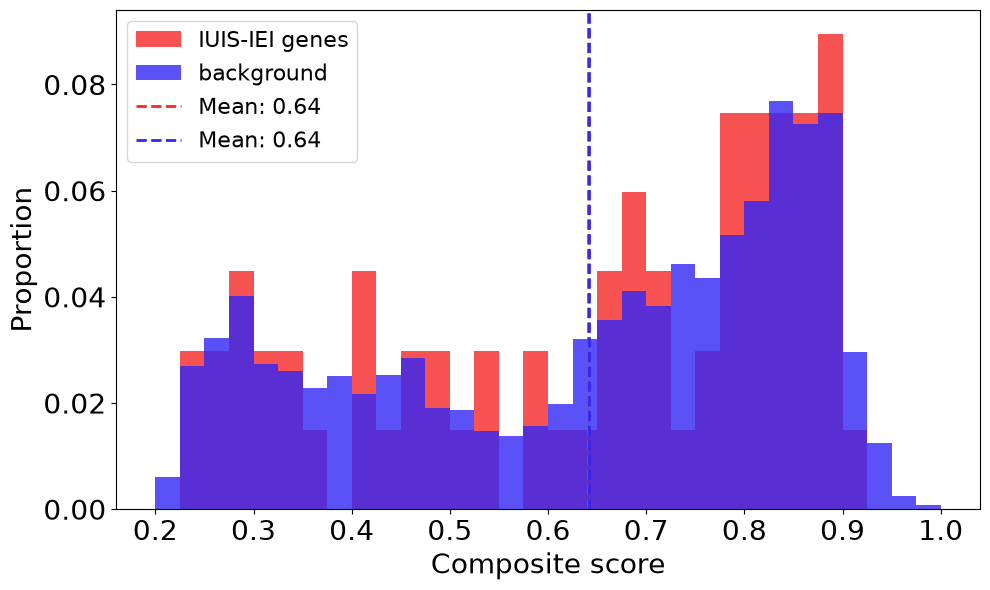

In [8]:
# ============================================================
#       Plot: IUIS-IEI vs background histogram
# ============================================================

df_comp_backg = df_comp_score.filter(
    ~pl.col("human_entryId").is_in(
        df_iuis_iei["Uniprot"].implode()
    )
)

df_comp_backg_unique = (
    df_comp_backg
    .sort("composite_score", descending=True)
    .unique("human_entryId", keep="first")
).sort("composite_score", descending=True)


def double_hist(
    col_1: pl.Series,
    col_2: pl.Series,
    label_1: str,
    label_2: str,
    x_label: str,
    y_label: str,
    bin_width: float,
    colour_1: str = "#F52727",
    colour_2: str = "#3127F5",
    dims: tuple[int, int] = (10, 6),
    alpha: float = 0.8,
    axis_font_size: int = 20,
    label_font_size: int = 16,
    out: str | None = None,
    mean_lines: bool = False
) -> None:
    min_val = min(col_1.min(), col_2.min())
    max_val = max(col_1.max(), col_2.max())

    bins = np.arange(
        np.floor(min_val / bin_width) * bin_width,
        np.ceil(max_val / bin_width) * bin_width + bin_width,
        bin_width,
    )
    plt.figure(figsize=dims)
    plt.hist(
        col_1.drop_nulls().to_list(),
        bins=bins,
        alpha=alpha,
        label=label_1,
        color=colour_1,
        weights=np.ones(len(col_1.drop_nulls())) / len(col_1.drop_nulls()),
    )
    plt.hist(
        col_2.drop_nulls().to_list(),
        bins=bins,
        alpha=alpha,
        label=label_2,
        color=colour_2,
        weights=np.ones(len(col_2.drop_nulls())) / len(col_2.drop_nulls()),
    )
    if mean_lines:
        plt.axvline(col_1.mean(), color=colour_1, linestyle="--", linewidth=2, label=f"Mean: {col_1.mean():.2f}")
        plt.axvline(col_2.mean(), color=colour_2, linestyle="--", linewidth=2, label=f"Mean: {col_2.mean():.2f}")

    plt.xlabel(x_label, fontsize=axis_font_size)
    plt.ylabel(y_label, fontsize=axis_font_size)
    plt.xticks(fontsize=axis_font_size)
    plt.yticks(fontsize=axis_font_size)
    plt.legend(fontsize=label_font_size)
    plt.tight_layout()

    if out is not None:
        plt.savefig(f"{out}.svg")
        plt.savefig(f"{out}.png", dpi=1080)

    plt.show()
    return None

double_hist(
    col_1=df_comp_iei_unique["composite_score"],
    col_2=df_comp_backg_unique["composite_score"],
    label_1="IUIS-IEI genes",
    label_2="background",
    x_label="Composite score",
    y_label="Proportion",
    bin_width=0.025,
    alpha=0.8,
    out=f"{OUT_DIR_PLOT}/hist_IUIS-IEI_background_byGeneName",
    mean_lines=True
)

In [9]:
# ============================================================
#       Permutation test: 2-sample diff in means
# ============================================================

def two_sample_permutation(
    sample_1: pl.Series,
    sample_2: pl.Series,
    iterations: int = 100000
) -> pl.DataFrame:

    data = pl.concat([sample_1, sample_2])
    n_1 = len(sample_1)
    n_2 = len(sample_2)

    sample_1_mean = []
    sample_2_mean = []
    diff_mean = []

    for _ in range(iterations):
        shuffled = data.sample(
            n = n_1 + n_2,
            with_replacement=False,
            shuffle=True
        )
        random_sample_1 = shuffled.head(n_1)
        random_sample_2 = shuffled.head(n_2)

        mean_1 = random_sample_1.mean()
        mean_2 = random_sample_2.mean()
        sample_1_mean.append(mean_1)
        sample_2_mean.append(mean_2)
        diff_mean.append(mean_1 - mean_2)

    return pl.DataFrame({
        "sample_1_mean": sample_1_mean,
        "sample_2_mean": sample_2_mean,
        "diff_means": diff_mean,
    })

df_permutations = two_sample_permutation(
    sample_1=df_comp_iei_unique["composite_score"],
    sample_2=df_comp_backg_unique["composite_score"]
)

df_permutations

sample_1_mean,sample_2_mean,diff_means
f64,f64,f64
0.652012,0.642841,0.009171
0.653509,0.642961,0.010548
0.66044,0.641324,0.019116
0.657593,0.64112,0.016472
0.651404,0.642011,0.009393
…,…,…
0.65627,0.641876,0.014395
0.617584,0.641485,-0.023902
0.711343,0.642169,0.069174


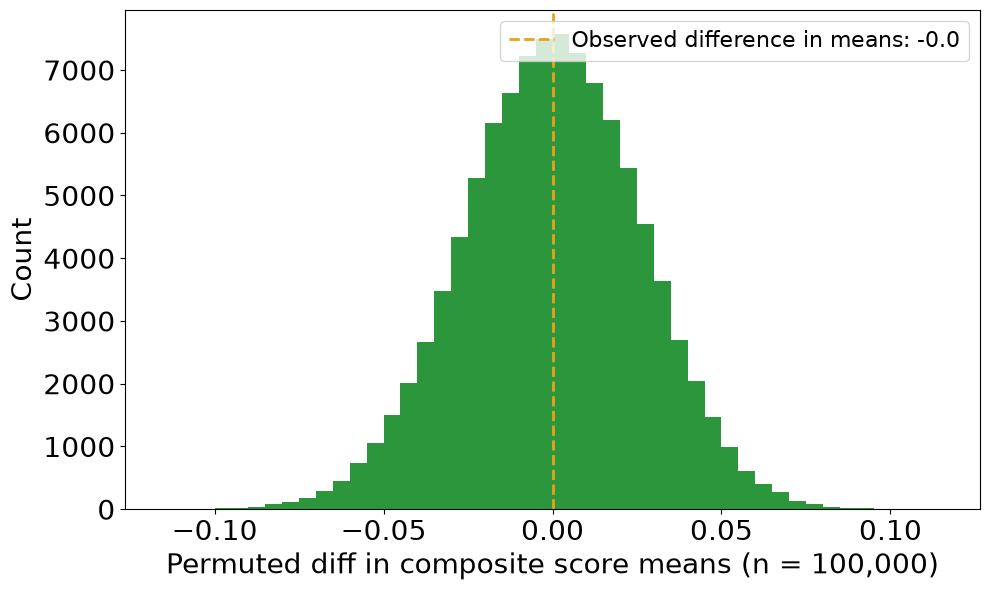

In [10]:
# ============================================================
#       Plot: permutation hist
# ============================================================

def permutation_hist(
    permutation_diffs: pl.Series,
    observed_diff: float,
    bin_width: float,
    x_label: str = "Permuted difference in means",
    y_label: str = "Count",
    colour_1: str = "#2C963C",
    colour_2: str = "#EDA01C",
    dims: tuple[int, int] = (10, 6),
    alpha: float = 1.0,
    axis_font_size: int = 20,
    label_font_size: int = 16,
    out: str | None = None,
) -> None:
    bins = np.arange(
        np.floor(min(permutation_diffs) / bin_width) * bin_width,
        np.ceil(max(permutation_diffs) / bin_width) * bin_width + bin_width,
        bin_width,
    )
    plt.figure(figsize=dims)
    plt.hist(
        permutation_diffs.drop_nulls().to_list(),
        bins=bins,
        alpha=alpha,
        color=colour_1,
    )
    plt.axvline(observed_diff, color=colour_2, linestyle="--", linewidth=2, label=f"Observed difference in means: {observed_diff}")
    plt.xlabel(x_label, fontsize=axis_font_size)
    plt.ylabel(y_label, fontsize=axis_font_size)
    plt.xticks(fontsize=axis_font_size)
    plt.yticks(fontsize=axis_font_size)
    plt.legend(fontsize=label_font_size)
    plt.tight_layout()

    if out is not None:
        plt.savefig(f"{out}.svg")
        plt.savefig(f"{out}.png", dpi=1080)

    plt.show()
    return None

observed_diff = df_comp_iei_unique["composite_score"].mean() - df_comp_backg_unique["composite_score"].mean()
permutation_hist(
    permutation_diffs=df_permutations["diff_means"],
    observed_diff=round(observed_diff, 2),
    x_label=f"Permuted diff in composite score means (n = {len(df_permutations):,})",
    bin_width=0.005,
    out=f"{OUT_DIR_PLOT}/hist_diff_means_permute_IUIS-IEI_byGeneName"
)

In [11]:
# ============================================================
#       Compute significance
# ============================================================

def p_val_permutation(
    permutation_diffs: pl.Series,
    observed_diff: float,
) -> float:
    k = len(permutation_diffs.filter(
        permutation_diffs >= abs(observed_diff)
    ))
    p = (k + 1) / (len(permutation_diffs) + 1)
    return p

p = p_val_permutation(
    permutation_diffs=df_permutations["diff_means"],
    observed_diff=round(observed_diff, 2)
)
logger.info(f"Composite score IUIS-IEI p-value: {round(p, 8)}")

INFO:__main__:Composite score IUIS-IEI p-value: 0.50261497
